In [2]:
from pathlib import Path
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Použité zariadenie:", device)

Použité zariadenie: cpu


In [4]:
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "casting"
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TRAIN_DIR exists:", TRAIN_DIR.exists())
print("TEST_DIR exists:", TEST_DIR.exists())

PROJECT_ROOT: c:\Users\42191\Desktop\skola\LS 25_26\Tímový Projekt
TRAIN_DIR exists: True
TEST_DIR exists: True


In [5]:
raw_train_dataset = datasets.ImageFolder(TRAIN_DIR)
raw_test_dataset = datasets.ImageFolder(TEST_DIR)

print("Triedy:", raw_train_dataset.classes)
print("Mapovanie tried:", raw_train_dataset.class_to_idx)
print("Počet obrázkov v train:", len(raw_train_dataset))
print("Počet obrázkov v test:", len(raw_test_dataset))

Triedy: ['def_front', 'ok_front']
Mapovanie tried: {'def_front': 0, 'ok_front': 1}
Počet obrázkov v train: 1057
Počet obrázkov v test: 243


In [6]:
IMG_SIZE = 128
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [7]:
full_train_for_split = datasets.ImageFolder(TRAIN_DIR)

train_size = int(0.8 * len(full_train_for_split))
val_size = len(full_train_for_split) - train_size

train_subset, val_subset = random_split(
    full_train_for_split,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_indices = train_subset.indices
val_indices = val_subset.indices

train_dataset = Subset(datasets.ImageFolder(TRAIN_DIR, transform=train_transform), train_indices)
val_dataset = Subset(datasets.ImageFolder(TRAIN_DIR, transform=eval_transform), val_indices)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

class_names = datasets.ImageFolder(TRAIN_DIR).classes

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))
print("Classes:", class_names)

Train: 845
Val: 212
Test: 243
Classes: ['def_front', 'ok_front']


In [8]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

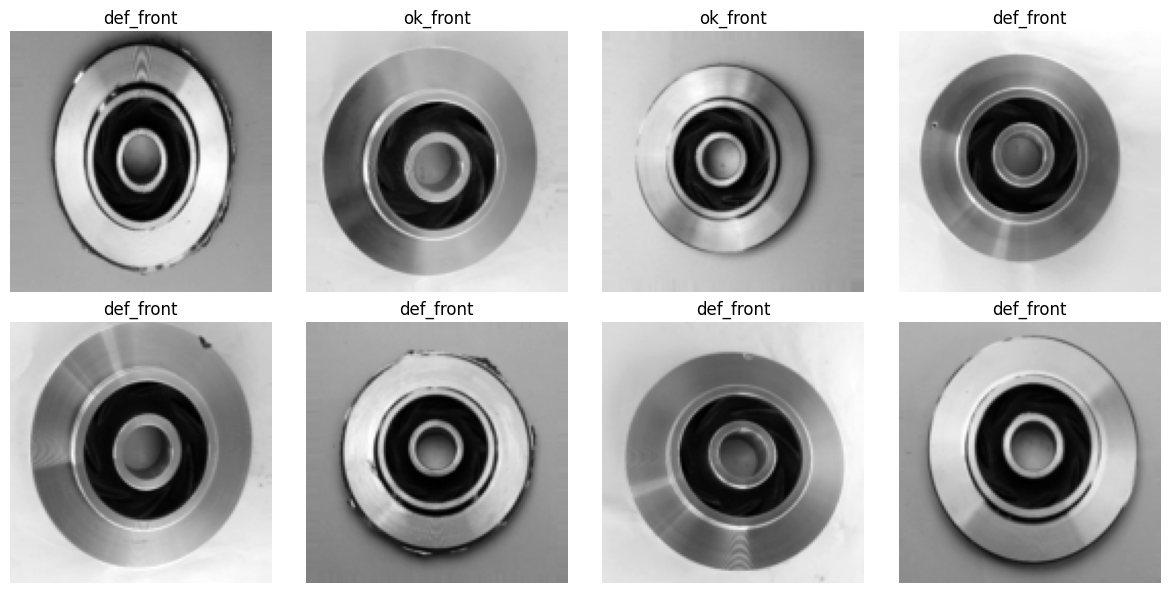

In [9]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(min(8, len(images))):
    plt.subplot(2, 4, i + 1)
    img = images[i].squeeze().numpy()
    img = img * 0.5 + 0.5  # denormalizácia kvôli zobrazeniu
    plt.imshow(img, cmap="gray")
    plt.title(class_names[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (IMG_SIZE // 8) * (IMG_SIZE // 8), 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = SimpleCNN(num_classes=len(class_names)).to(device)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [13]:
EPOCHS = 8

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_loss = float("inf")
best_model_state = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

model.load_state_dict(best_model_state)

Epoch 1/8 | train_loss=0.5497, train_acc=0.7302 | val_loss=0.4623, val_acc=0.7547
Epoch 2/8 | train_loss=0.4843, train_acc=0.7550 | val_loss=0.4062, val_acc=0.8113
Epoch 3/8 | train_loss=0.4121, train_acc=0.7929 | val_loss=0.3531, val_acc=0.8255
Epoch 4/8 | train_loss=0.3591, train_acc=0.8213 | val_loss=0.3538, val_acc=0.8443
Epoch 5/8 | train_loss=0.3279, train_acc=0.8438 | val_loss=0.3069, val_acc=0.8491
Epoch 6/8 | train_loss=0.2684, train_acc=0.8923 | val_loss=0.2681, val_acc=0.8585
Epoch 7/8 | train_loss=0.2130, train_acc=0.9006 | val_loss=0.2403, val_acc=0.8821
Epoch 8/8 | train_loss=0.1977, train_acc=0.9172 | val_loss=0.2523, val_acc=0.8821


<All keys matched successfully>

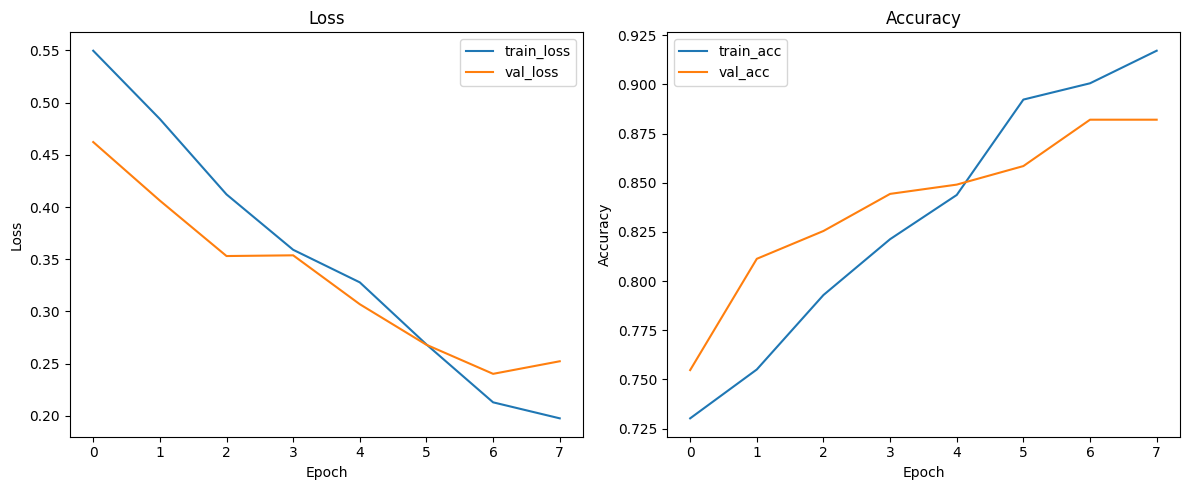

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="train_acc")
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 0.1868
Test accuracy: 0.9218


              precision    recall  f1-score   support

   def_front       0.98      0.90      0.94       155
    ok_front       0.84      0.97      0.90        88

    accuracy                           0.92       243
   macro avg       0.91      0.93      0.92       243
weighted avg       0.93      0.92      0.92       243



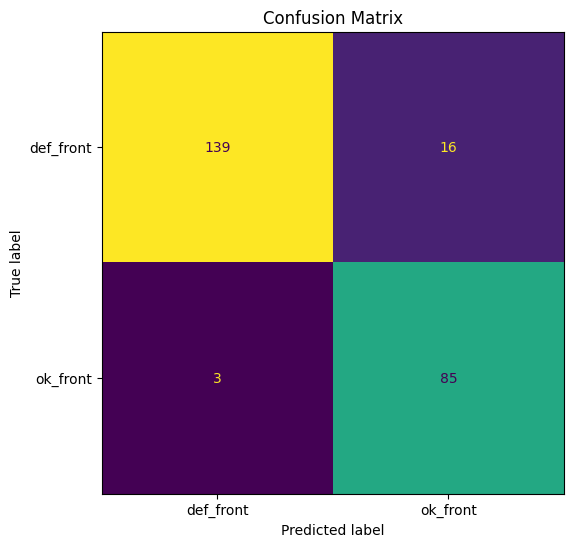

In [16]:
def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)


y_true, y_pred = get_predictions(model, test_loader, device)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, colorbar=False)
plt.title("Confusion Matrix")
plt.show()

In [17]:
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

torch.save(model.state_dict(), MODELS_DIR / "simple_cnn_casting.pth")
print("Model uložený.")

Model uložený.
